# Week 13 & 14 — Ensembles, Bias–Variance, Over/Underfitting, Regularization
**Hack-O-Week | 5th Semester | SIT Nagpur**

1. Ensemble methods: Bagging, Boosting (XGBoost, LightGBM)
2. Bias–variance trade-off, overfitting / underfitting, regularization (L1 / L2)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings; warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, mean_squared_error
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
np.random.seed(0)
X,y = load_breast_cancer(return_X_y=True)
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.25,random_state=42,stratify=y)

## Part A — Ensemble Methods
**Idea:** "Many weak/average models together beat one model." (Wisdom of the crowd.)

### 1. Bagging (Bootstrap Aggregating) — reduces **variance**
**Steps:**
1. Make many random samples **with replacement** (bootstrap samples) from training data.
2. Train one model (usually a deep Decision Tree) on each sample **independently**.
3. **Combine:** majority vote (classification) or average (regression).

**Random Forest** = Bagging + random subset of features at every split (more diversity).

### 2. Boosting — reduces **bias**
**Steps:**
1. Train a simple model (shallow tree).
2. Find the mistakes it made.
3. Train the next model to **focus on those mistakes** (higher weights / fit residuals).
4. Repeat; combine all models with weights.
Models are trained **one after another** (sequential), unlike bagging (parallel).

In [2]:
models = {
 'Single Decision Tree': DecisionTreeClassifier(random_state=0),
 'Bagging (50 trees)': BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=0),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=0),
 'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=0),
 'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}
res=[]
for n,m in models.items():
    cv = cross_val_score(m,X,y,cv=5).mean(); m.fit(Xtr,ytr)
    res.append([n, round(cv,3), round(accuracy_score(yte,m.predict(Xte)),3)])
print(pd.DataFrame(res,columns=['Model','5-fold CV acc','Test acc']).to_string(index=False))

               Model  5-fold CV acc  Test acc
Single Decision Tree          0.917     0.937
  Bagging (50 trees)          0.961     0.944
       Random Forest          0.960     0.958
            AdaBoost          0.977     0.965
   Gradient Boosting          0.963     0.958


### 3. XGBoost (eXtreme Gradient Boosting)
Gradient boosting made fast and strong:
- Builds trees one by one, each fixing the **residual errors** of the previous ones (uses gradients).
- Built-in **L1/L2 regularization** (`reg_alpha`, `reg_lambda`) → less overfitting.
- Handles missing values, parallel tree construction, early stopping.
- Level-wise (depth-wise) tree growth.

**Important parameters:** `n_estimators`, `learning_rate` (small = safer), `max_depth`, `subsample`, `colsample_bytree`, `reg_lambda`.

### 4. LightGBM
Microsoft's fast gradient boosting:
- **Leaf-wise** tree growth (splits the leaf with the biggest loss reduction) → more accurate, faster; can overfit small data → control `num_leaves`, `min_child_samples`.
- **Histogram-based** splits (bins feature values) → low memory, very fast on big data.
- Native support for categorical features.

| | XGBoost | LightGBM |
|---|---|---|
| Tree growth | Level-wise | Leaf-wise |
| Speed on large data | Fast | Faster |
| Overfit risk on small data | Lower | Higher (tune num_leaves) |

XGBoost   CV acc = 0.974 | Test acc = 0.965


LightGBM  CV acc = 0.974 | Test acc = 0.965


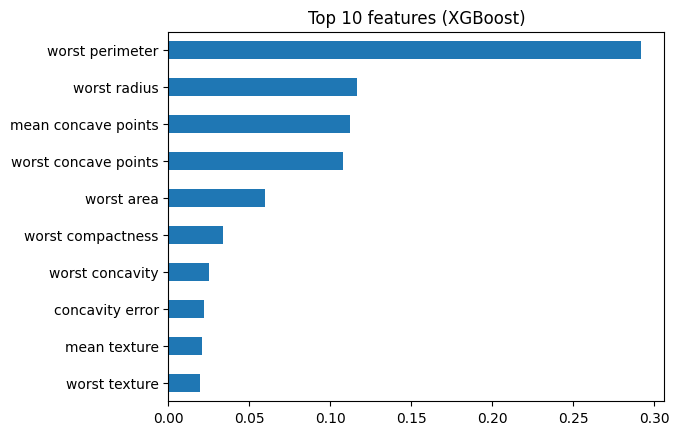

In [3]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8,
                    colsample_bytree=0.8, reg_lambda=1.0, eval_metric='logloss', random_state=0)
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, subsample=0.8,
                     colsample_bytree=0.8, random_state=0, verbose=-1)
for n,m in [('XGBoost',xgb),('LightGBM',lgb)]:
    m.fit(Xtr,ytr); print(f"{n:9s} CV acc = {cross_val_score(m,X,y,cv=5).mean():.3f} | Test acc = {accuracy_score(yte,m.predict(Xte)):.3f}")

# Feature importance (XGBoost)
imp = pd.Series(xgb.feature_importances_, index=load_breast_cancer().feature_names).sort_values().tail(10)
imp.plot.barh(title='Top 10 features (XGBoost)'); plt.show()

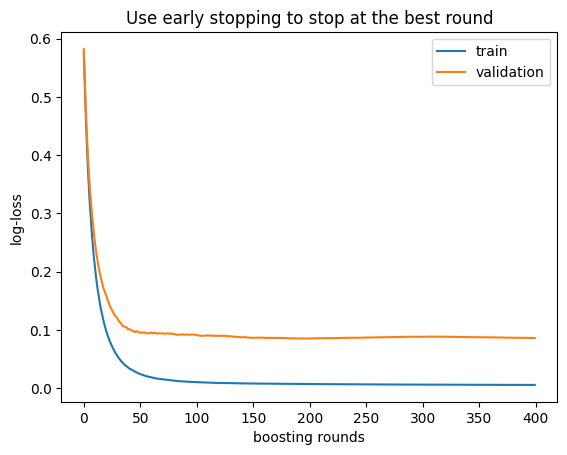

In [4]:
# Learning curve: more boosting rounds -> training error keeps falling; validation error starts to rise (overfit)
xg = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=0)
xg.fit(Xtr,ytr, eval_set=[(Xtr,ytr),(Xte,yte)], verbose=False)
r = xg.evals_result()
plt.plot(r['validation_0']['logloss'],label='train'); plt.plot(r['validation_1']['logloss'],label='validation')
plt.xlabel('boosting rounds'); plt.ylabel('log-loss'); plt.legend(); plt.title('Use early stopping to stop at the best round'); plt.show()

## Part B — Bias–Variance, Overfitting, Underfitting, Regularization
### 5. Bias–Variance Trade-off
- **Bias** = error from *too simple* assumptions (model misses the pattern) → **underfitting**.
- **Variance** = error from being *too sensitive* to training data (learns noise) → **overfitting**.
- **Total error = Bias² + Variance + Irreducible noise.**
- Simple model: high bias, low variance. Complex model: low bias, high variance. Aim for the **sweet spot**.

### 6. Underfitting vs Overfitting
| | Underfitting | Good fit | Overfitting |
|---|---|---|---|
| Train error | High | Low | Very low |
| Test error | High | Low | High |
| Cause | Too simple model, too few features, too much regularization | Right complexity | Too complex model, too little data, noise, too many epochs |
| Fix | More complex model, more features, less regularization | — | More data, simpler model, **regularization**, cross-validation, early stopping, dropout, pruning, ensembles(bagging) |

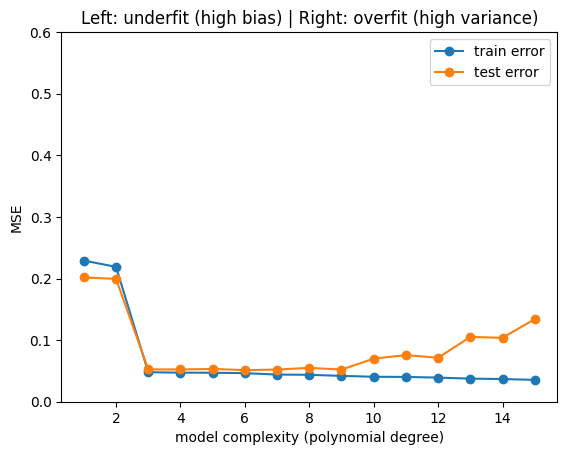

Best degree (lowest test error): 6


In [5]:
# Demonstration with polynomial degree
rng = np.random.RandomState(0)
x = np.sort(rng.uniform(0,1,60)); yy = np.sin(2*np.pi*x) + rng.normal(0,.25,60)
x_tr,x_te,y_tr,y_te = train_test_split(x.reshape(-1,1),yy,test_size=.4,random_state=1)
degs = range(1,16); tr,te=[],[]
for d in degs:
    m = make_pipeline(PolynomialFeatures(d),LinearRegression()).fit(x_tr,y_tr)
    tr.append(mean_squared_error(y_tr,m.predict(x_tr))); te.append(mean_squared_error(y_te,m.predict(x_te)))
plt.plot(degs,tr,'o-',label='train error'); plt.plot(degs,te,'o-',label='test error'); plt.ylim(0,.6)
plt.xlabel('model complexity (polynomial degree)'); plt.ylabel('MSE'); plt.legend()
plt.title('Left: underfit (high bias) | Right: overfit (high variance)'); plt.show()
print("Best degree (lowest test error):", list(degs)[int(np.argmin(te))])

### 7. Regularization (L1 / L2)
**Idea:** Add a penalty for large weights to the loss, so the model stays simple and generalises better.

`Loss_new = Loss_original + λ · Penalty(weights)`

- **L2 (Ridge):** Penalty = Σw². Shrinks all weights smoothly; keeps all features.
- **L1 (Lasso):** Penalty = Σ|w|. Makes some weights exactly 0 → automatic **feature selection**.
- **Elastic Net:** mix of L1 + L2.
- λ (alpha) big → underfit; λ small → overfit. Choose by cross-validation.
- In `LogisticRegression` the parameter is `C = 1/λ` (smaller C = stronger regularization).

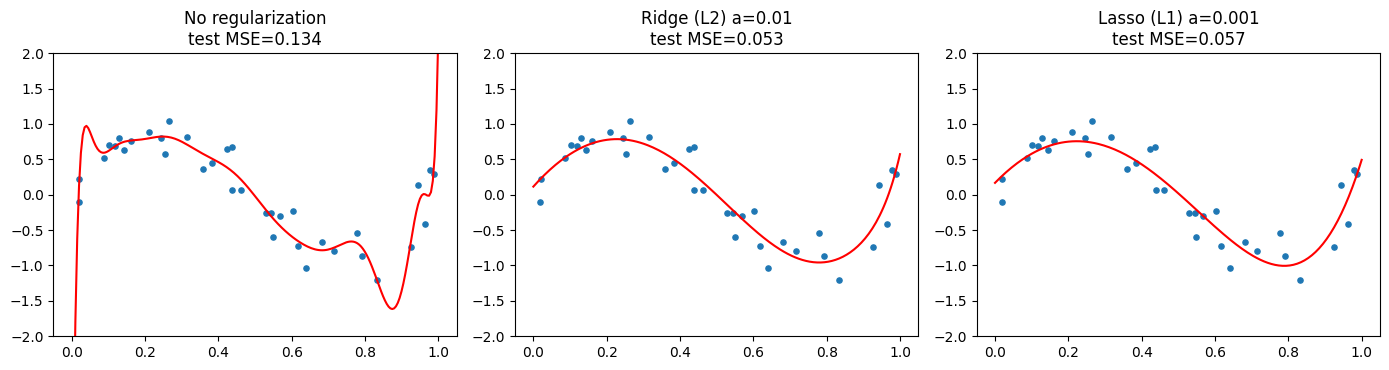

In [6]:
# Degree-15 polynomial: no regularization vs Ridge vs Lasso
grid = np.linspace(0,1,200).reshape(-1,1)
plt.figure(figsize=(14,3.8))
for i,(name,reg) in enumerate([('No regularization',LinearRegression()),('Ridge (L2) a=0.01',Ridge(alpha=0.01)),('Lasso (L1) a=0.001',Lasso(alpha=0.001,max_iter=200000))],1):
    m = make_pipeline(PolynomialFeatures(15),StandardScaler(),reg).fit(x_tr,y_tr)
    plt.subplot(1,3,i); plt.scatter(x_tr,y_tr,s=14); plt.plot(grid,m.predict(grid),'r'); plt.ylim(-2,2)
    plt.title(f"{name}\ntest MSE={mean_squared_error(y_te,m.predict(x_te)):.3f}")
plt.tight_layout(); plt.show()

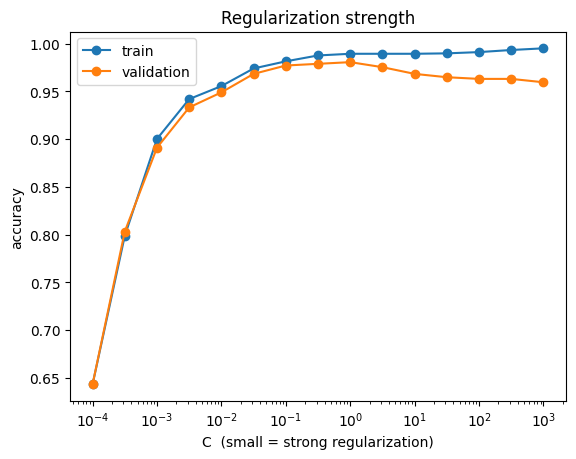

Best C: 1.0
L2: zero weights = 0 of 30, test acc = 0.986
L1: zero weights = 23 of 30, test acc = 0.972


In [7]:
# Choosing the regularization strength with a validation curve (Logistic Regression, parameter C)
Cs = np.logspace(-4,3,15)
tr_s,va_s = validation_curve(make_pipeline(StandardScaler(),LogisticRegression(max_iter=5000)),X,y,
                             param_name='logisticregression__C',param_range=Cs,cv=5)
plt.semilogx(Cs,tr_s.mean(1),'o-',label='train'); plt.semilogx(Cs,va_s.mean(1),'o-',label='validation')
plt.xlabel('C  (small = strong regularization)'); plt.ylabel('accuracy'); plt.legend(); plt.title('Regularization strength'); plt.show()
print("Best C:", Cs[int(np.argmax(va_s.mean(1)))].round(4))

# L1 vs L2 weights in logistic regression
for pen in ['l2','l1']:
    lr = make_pipeline(StandardScaler(),LogisticRegression(penalty=pen,solver='liblinear',C=0.1)).fit(Xtr,ytr)
    w = lr[-1].coef_[0]; print(f"{pen.upper()}: zero weights = {(w==0).sum()} of {len(w)}, test acc = {lr.score(Xte,yte):.3f}")

## Summary
| Topic | Key point |
|---|---|
| Bagging | Parallel models on bootstrap samples, average → **lower variance** (Random Forest) |
| Boosting | Sequential models fix previous errors → **lower bias** |
| XGBoost | Regularized gradient boosting, level-wise trees, robust |
| LightGBM | Leaf-wise, histogram based, very fast on large data |
| Bias | Error from too simple model (underfit) |
| Variance | Error from too complex model (overfit) |
| Regularization | L2 shrinks weights, L1 zeroes weights; tune λ by cross-validation |

**Overfit checklist:** compare train vs test score → if gap is big, use more data / regularization / simpler model / early stopping / bagging.